In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, avg
import matplotlib.pyplot as plt

In [2]:
spark = SparkSession.builder \
    .appName("Big Data Analysis - Amazon Reviews") \
    .getOrCreate()

print("Spark Session Created")

Spark Session Created


In [9]:
df = spark.read.csv(
    "Reviews.csv",
    header=True,
    inferSchema=True,
    multiLine=True,
    escape='"'
)

In [11]:
df.printSchema()

root
 |-- Id: integer (nullable = true)
 |-- ProductId: string (nullable = true)
 |-- UserId: string (nullable = true)
 |-- ProfileName: string (nullable = true)
 |-- HelpfulnessNumerator: integer (nullable = true)
 |-- HelpfulnessDenominator: integer (nullable = true)
 |-- Score: integer (nullable = true)
 |-- Time: integer (nullable = true)
 |-- Summary: string (nullable = true)
 |-- Text: string (nullable = true)



In [12]:
from pyspark.sql.functions import col

df = df.withColumn("Score", col("Score").cast("int"))

In [13]:
df = df.filter(col("Score").isNotNull())

In [5]:
row_count = df.count()
column_count = len(df.columns)

print("Total Rows:", row_count)
print("Total Columns:", column_count)

Total Rows: 568454
Total Columns: 10


In [6]:
df = df.select("ProductId","Score","Summary","Text")

df = df.dropna()

df.show(5)

+----------+-----+--------------------+--------------------+
| ProductId|Score|             Summary|                Text|
+----------+-----+--------------------+--------------------+
|B001E4KFG0|    5|Good Quality Dog ...|I have bought sev...|
|B00813GRG4|    1|   Not as Advertised|"Product arrived ...|
|B000LQOCH0|    4|"""Delight"" says...|"This is a confec...|
|B000UA0QIQ|    2|      Cough Medicine|If you are lookin...|
|B006K2ZZ7K|    5|         Great taffy|Great taffy at a ...|
+----------+-----+--------------------+--------------------+
only showing top 5 rows


In [7]:
rating_distribution = df.groupBy("Score").count().orderBy("Score")

rating_distribution.show()

+--------------+-----+
|         Score|count|
+--------------+-----+
|          ..."|   23|
|     Author"""|    3|
|   Comp sci"""|    1|
|     Critic"""|    1|
|        Dad"""|    1|
|     Dance..."|    4|
|        Design|    1|
|        Ed..."|    1|
|       Hugs"""|    1|
|     Lyme ..."|    1|
|     Medit..."|    2|
|        Moscow|    1|
| Music Fan..."|    8|
|         RN"""|   23|
|        Sm..."|    1|
|      USA ..."|    1|
|   Video Games|    1|
|         a..."|   10|
|     and F..."|    1|
| and Kitten"""|  104|
+--------------+-----+
only showing top 20 rows


In [14]:
from pyspark.sql.functions import avg, count

product_rating = df.groupBy("ProductId") \
                   .agg(avg("Score").alias("Average_Rating"),
                        count("Score").alias("Total_Reviews")) \
                   .orderBy(col("Total_Reviews").desc())

product_rating.show(10)

+----------+------------------+-------------+
| ProductId|    Average_Rating|Total_Reviews|
+----------+------------------+-------------+
|B007JFMH8M|4.5826944140197154|          913|
|B002QWHJOU|4.5886075949367084|          632|
|B002QWP89S|4.5886075949367084|          632|
|B0026RQTGE|4.5886075949367084|          632|
|B002QWP8H0|4.5886075949367084|          632|
|B003B3OOPA| 4.739967897271268|          623|
|B001EO5Q64| 4.746031746031746|          567|
|B007M832YY| 4.310283687943262|          564|
|B001RVFERK| 4.310283687943262|          564|
|B0026KNQSA| 4.310283687943262|          564|
+----------+------------------+-------------+
only showing top 10 rows


In [15]:
top_products = df.groupBy("ProductId") \
                 .count() \
                 .orderBy(col("count").desc())

top_products.show(10)

+----------+-----+
| ProductId|count|
+----------+-----+
|B007JFMH8M|  913|
|B002QWHJOU|  632|
|B002QWP89S|  632|
|B0026RQTGE|  632|
|B002QWP8H0|  632|
|B003B3OOPA|  623|
|B001EO5Q64|  567|
|B007M832YY|  564|
|B001RVFERK|  564|
|B0026KNQSA|  564|
+----------+-----+
only showing top 10 rows


In [16]:
rating_pd = rating_distribution.toPandas()

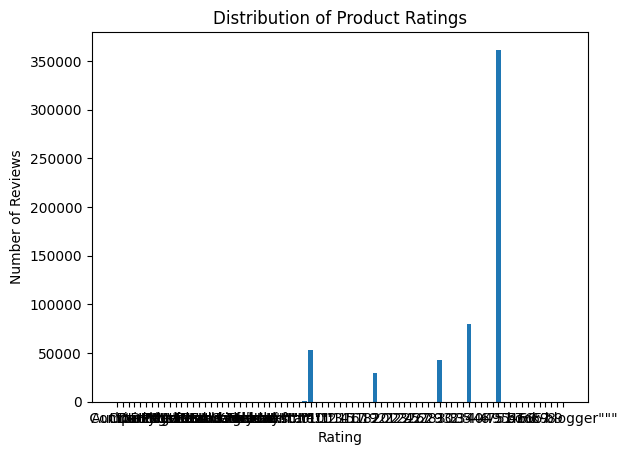

In [17]:
plt.bar(rating_pd['Score'], rating_pd['count'])

plt.title("Distribution of Product Ratings")

plt.xlabel("Rating")

plt.ylabel("Number of Reviews")

plt.show()

In [18]:
positive_reviews = df.filter(col("Score") >= 4).count()

negative_reviews = df.filter(col("Score") <= 2).count()

print("Positive Reviews:", positive_reviews)

print("Negative Reviews:", negative_reviews)

Positive Reviews: 443777
Negative Reviews: 82037
